[np.float64(1.0123065780834357), np.float64(0.056729281641146656), np.float64(0.02231460282383324), np.float64(0.01213104760167072), np.float64(0.007653461670068751), np.float64(0.0052757172536299635), np.float64(0.0038592730011557386), np.float64(0.002946605467042396), np.float64(0.0023238308748370073), np.float64(0.0018798075837702655)]


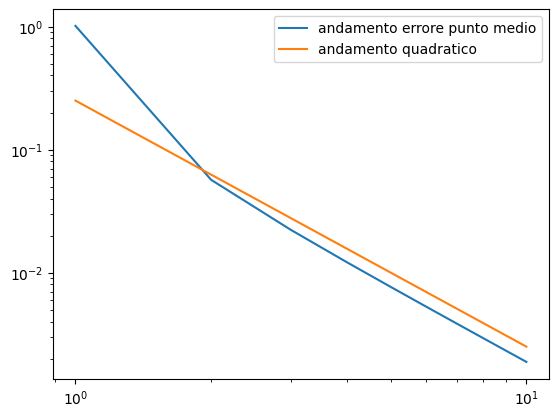

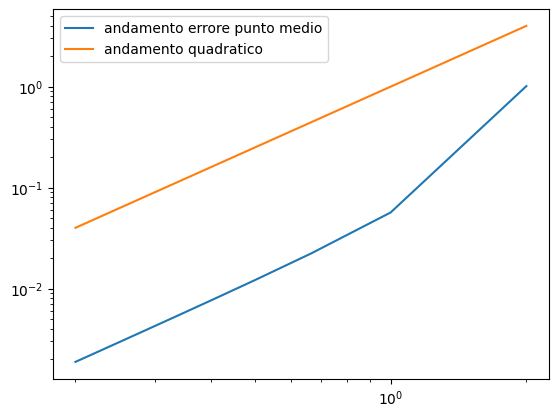

In [11]:
#tde 31/08/2022
#es.2)
import numpy as np
import matplotlib.pyplot as plt

def pmedcomp(f, a, b, N):
  """
  Formula del punto medio composita
  Input:
     f:   funzione da integrare
     a:   estremo sinistro dell'intervallo di integrazione
     b:   estremo destro dell'intervallo di integrazione
     N:   numero di sottointervalli (N = 1 formula di integrazione semplice)
  Output:
     I:   integrale approssimato
  """
  #ampiezza di ciascun sottoi-intervallo
  h=(b-a)/N
  #griglia di punti
  x=np.linspace(a, b, N+1)

  #vettore degli estremi sinistri (left -> L) di ciascun sotto-intervallo
  xL=x[:-1] #estraggo dal vettore x tutti i nodi a partire dal primo fino all'ultimo escluso (x0=a fino a x(n-1), ossia il nodo prima di b=x(n))

  #vettore degli estremi destri (right -> R)
  xR=x[1:] #estraggo dal vettore x tutti i nodi escluso il primo, fino all'ultimo incluso
  #si possono combinare xL e xR per creare il vettore dei punti medi
  xM=(xL+xR)/2 #si sommano punto a punto/componente a componente i due vettori e si divide per due, così da trovare
  #tutti i punti medi di ciascun sotto-intervallo

  #calcolo integrale (punto medio)
  I=h*f(xM).sum() #array.sum()  calcola la somma di tutte le sue componenti nel np.array

  return I

#risoluzione esercizio
f=lambda x: x**2*np.sin(x)**3
a=0
b=2

N_list=[1,2,3,4,5,6,7,8,9,10]
I_esatto=lambda x:1/108*(-81*(-2+x**2)*np.cos(x)+(-2+9*x**2)*np.cos(3*x)-6*x*(-27*np.sin(x)+np.sin(3*x)))
I_ex=I_esatto(b)-I_esatto(a)
err_pm=[]
h=[]
for n in N_list:
  h.append((b-a)/n)
  I_pm=pmedcomp(f, a, b, n)
  err_pm.append(np.abs(I_ex-I_pm))

print(err_pm)

#andamento grafico dell'errore del metodo di quadratura del punto medio composito
h=np.array(h)
N_list=np.array(N_list)
plt.figure()
plt.loglog(N_list, err_pm, label='andamento errore punto medio')
plt.loglog(N_list, (0.5/N_list)**2, label='andamento quadratico')
plt.legend()
plt.show()
#oppure, valutando h invece che N_list, quindi al diminuire di h:
plt.figure()
plt.loglog(h, err_pm, label='andamento errore punto medio')
plt.loglog(h, h**2, label='andamento quadratico')
plt.legend()
plt.show()


[np.float64(0.8033547274106243), np.float64(0.1044759253364056), np.float64(0.043274400597431484), np.float64(0.02387332184762947), np.float64(0.015154818607225895), np.float64(0.0104798988867989), np.float64(0.007680514967961294), np.float64(0.005871137122979153), np.float64(0.0046339744194559), np.float64(0.003750678468578794)]


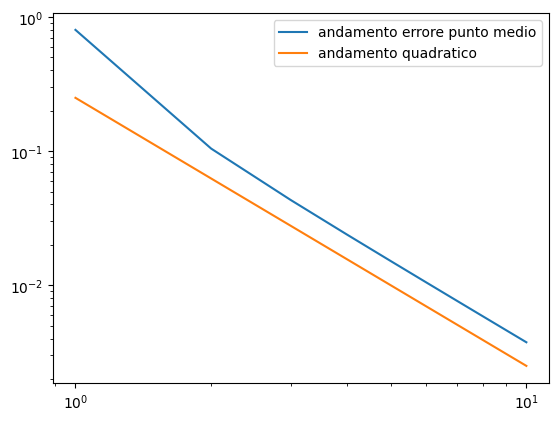

In [14]:
#b)

def trapcomp(f, a, b, N):
  """
  Formula dei trapezi composita
  Input:
     f:   funzione da integrare
     a:   estremo sinistro dell'intervallo di integrazione
     b:   estremo destro dell'intervallo di integrazione
     N:   numero di sottointervalli (N = 1 formula di integrazione semplice)
  Output:
     I:   integrale approssimato
  """
  #ampiezza di ciascun sotto-intervallo
  h=(b-a)/N
  #griglia di punti
  x=np.linspace(a, b, N+1)

  #vettore degli estremi sinistri (left -> L) di ciascun sotto-intervallo (T=trapezi)
  xL_T=x[:-1] 
  #vettore degli estremi destri (right -> R)
  xR_T=x[1:]
  
  #calcolo integrale (punto medio)
  I=h/2*(f(xL_T)+f(xR_T)).sum() #array.sum() calcola la somma di tutte le sue componenti nel np.array
  return I

#risoluzione esercizio
err_tr=[]
h=[]
for n in N_list:
  h.append((b-a)/n)
  I_trap=trapcomp(f, a, b, n)
  err_tr.append(np.abs(I_ex-I_trap))

print(err_tr)

#andamento grafico dell'errore del metodo di quadratura del punto medio composito
h=np.array(h)
N_list=np.array(N_list)
plt.figure()
plt.loglog(N_list, err_tr, label='andamento errore punto medio')
plt.loglog(N_list, (0.5/N_list)**2, label='andamento quadratico')
plt.legend()
plt.show()



In [ ]:
#così come anche il metodo di quadratura del punto medio, anche il metodo dei trapezi composito
#ha un errore che decresce come il quadrato del numero di intervalli -> cresce come il quadrato del
#passo temporale h. Ha come quello di punto medio ordine di accuratezza 2 e grado di esattezza 1.

[np.float64(0.8033547274106243), np.float64(0.1044759253364056), np.float64(0.043274400597431484), np.float64(0.02387332184762947), np.float64(0.015154818607225895), np.float64(0.0104798988867989), np.float64(0.007680514967961294), np.float64(0.005871137122979153), np.float64(0.0046339744194559), np.float64(0.003750678468578794)]


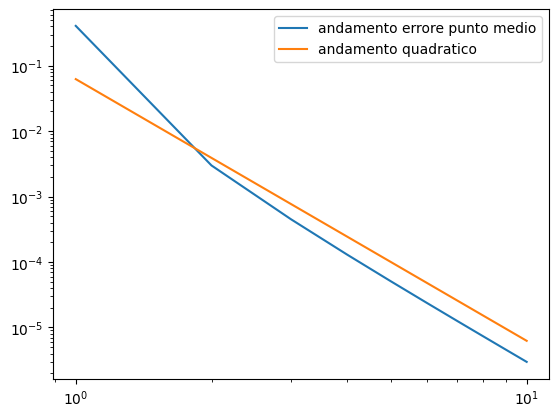

In [17]:
#c)
def simpcomp(f, a, b, N):
  """
  Formula di Cavalieri-Simpson composita
  Input:
     f:   funzione da integrare
     a:   estremo sinistro dell'intervallo di integrazione
     b:   estremo sinistro dell'intervallo di integrazione
     N:   numero di sottointervalli (N = 1 formula di integrazione semplice)
  Output:
     I:   integrale approssimato
  """
  #ampiezza di ciascun sotto-intervallo
  h=(b-a)/N
  #griglia di punti
  x=np.linspace(a, b, N+1)

  #vettore degli estremi sinistri (left -> L) di ciascun sotto-intervallo (S=Simpson)
  xL_S=x[:-1] 
  #vettore degli estremi destri (right -> R)
  xR_S=x[1:]
  #si possono combinare xL e xR per creare il vettore 
  xM_S=(xL_S+xR_S)/2
  
  #calcolo integrale (punto medio)
  I=h/6*(f(xL_S)+4*f(xM_S)+f(xR_S)).sum() #array.sum() calcola la somma di tutte le sue componenti nel np.array
  return I

#risoluzione esercizio
err_s=[]
h=[]
for n in N_list:
  h.append((b-a)/n)
  I_s=simpcomp(f, a, b, n)
  err_s.append(np.abs(I_ex-I_s))

print(err_tr)

#andamento grafico dell'errore del metodo di quadratura del punto medio composito
h=np.array(h)
N_list=np.array(N_list)
plt.figure()
plt.loglog(N_list, err_s, label='andamento errore punto medio')
plt.loglog(N_list, (0.5/N_list)**4, label='andamento quadratico')
plt.legend()
plt.show()

In [ ]:
#l'errore dei metodo di quadratura di simpson converge con ordine di accuratezza 4 e ha
#grado di esattezza pari a 3.